In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import joblib as jb

In [2]:
IN_KAGGLE = os.path.exists( '/kaggle/input' )

if IN_KAGGLE :
    DATA_DIR = Path( 'Multi-Class Prediction of Obesity Risk/' )

else :
    DATA_DIR = Path.cwd().parent / 'datasets' / 'raw'

train_data = pd.read_csv( DATA_DIR / 'train.csv')
test_data = pd.read_csv( DATA_DIR / 'test.csv')

train_data.shape , test_data.shape

((20758, 18), (13840, 17))

#### Features Extraction

In [3]:
# BMI is the strongest predictor of obesity class - always derive it first
train_data['BMI'] = train_data['Weight'] / (train_data['Height'] ** 2)

# Weight-to-height ratio (linear, complements the squared BMI relationship)
train_data['Weight_Height_Ratio'] = train_data['Weight'] / train_data['Height']

# Ideal weight estimate (Devine formula approximation) and deviation from it
train_data['Ideal_Weight'] = (train_data['Height'] - 1.5) * 50 + 50
train_data['Weight_Deviation'] = train_data['Weight'] - train_data['Ideal_Weight']

In [4]:
test_data['BMI'] = test_data['Weight'] / (test_data['Height'] ** 2)

test_data['Weight_Height_Ratio'] = test_data['Weight'] / test_data['Height']

test_data['Ideal_Weight'] = (test_data['Height'] - 1.5) * 50 + 50
test_data['Weight_Deviation'] = test_data['Weight'] - test_data['Ideal_Weight']

In [5]:
train_data['FCVC_NCP_Ratio'] = train_data['FCVC'] / (train_data['NCP'] + 1e-6)

train_data['FAF_TUE_Ratio'] = train_data['FAF'] / (train_data['TUE'] + 1e-6)

In [6]:
test_data['FCVC_NCP_Ratio'] = test_data['FCVC'] / (test_data['NCP'] + 1e-6)

test_data['FAF_TUE_Ratio'] = test_data['FAF'] / (test_data['TUE'] + 1e-6)

In [7]:
# Age groups often behave non-linearly with obesity risk
train_data['Age_Group'] = pd.cut(
    train_data['Age'],
    bins=[0, 18, 25, 35, 50, 100],
    labels=['Teen', 'Young_Adult', 'Adult', 'Middle_Age', 'Senior']
)

In [8]:
test_data['Age_Group'] = pd.cut(
    test_data['Age'],
    bins=[0, 18, 25, 35, 50, 100],
    labels=['Teen', 'Young_Adult', 'Adult', 'Middle_Age', 'Senior']
)

In [9]:
# Active vs passive transportation as a binary indicator
active_transport = ['Walking', 'Bike']
train_data['Active_Transport'] = train_data['MTRANS'].isin(active_transport).astype(int)

In [10]:
active_transport = ['Walking', 'Bike']
test_data['Active_Transport'] = test_data['MTRANS'].isin(active_transport).astype(int)

#### Visualize Correlation

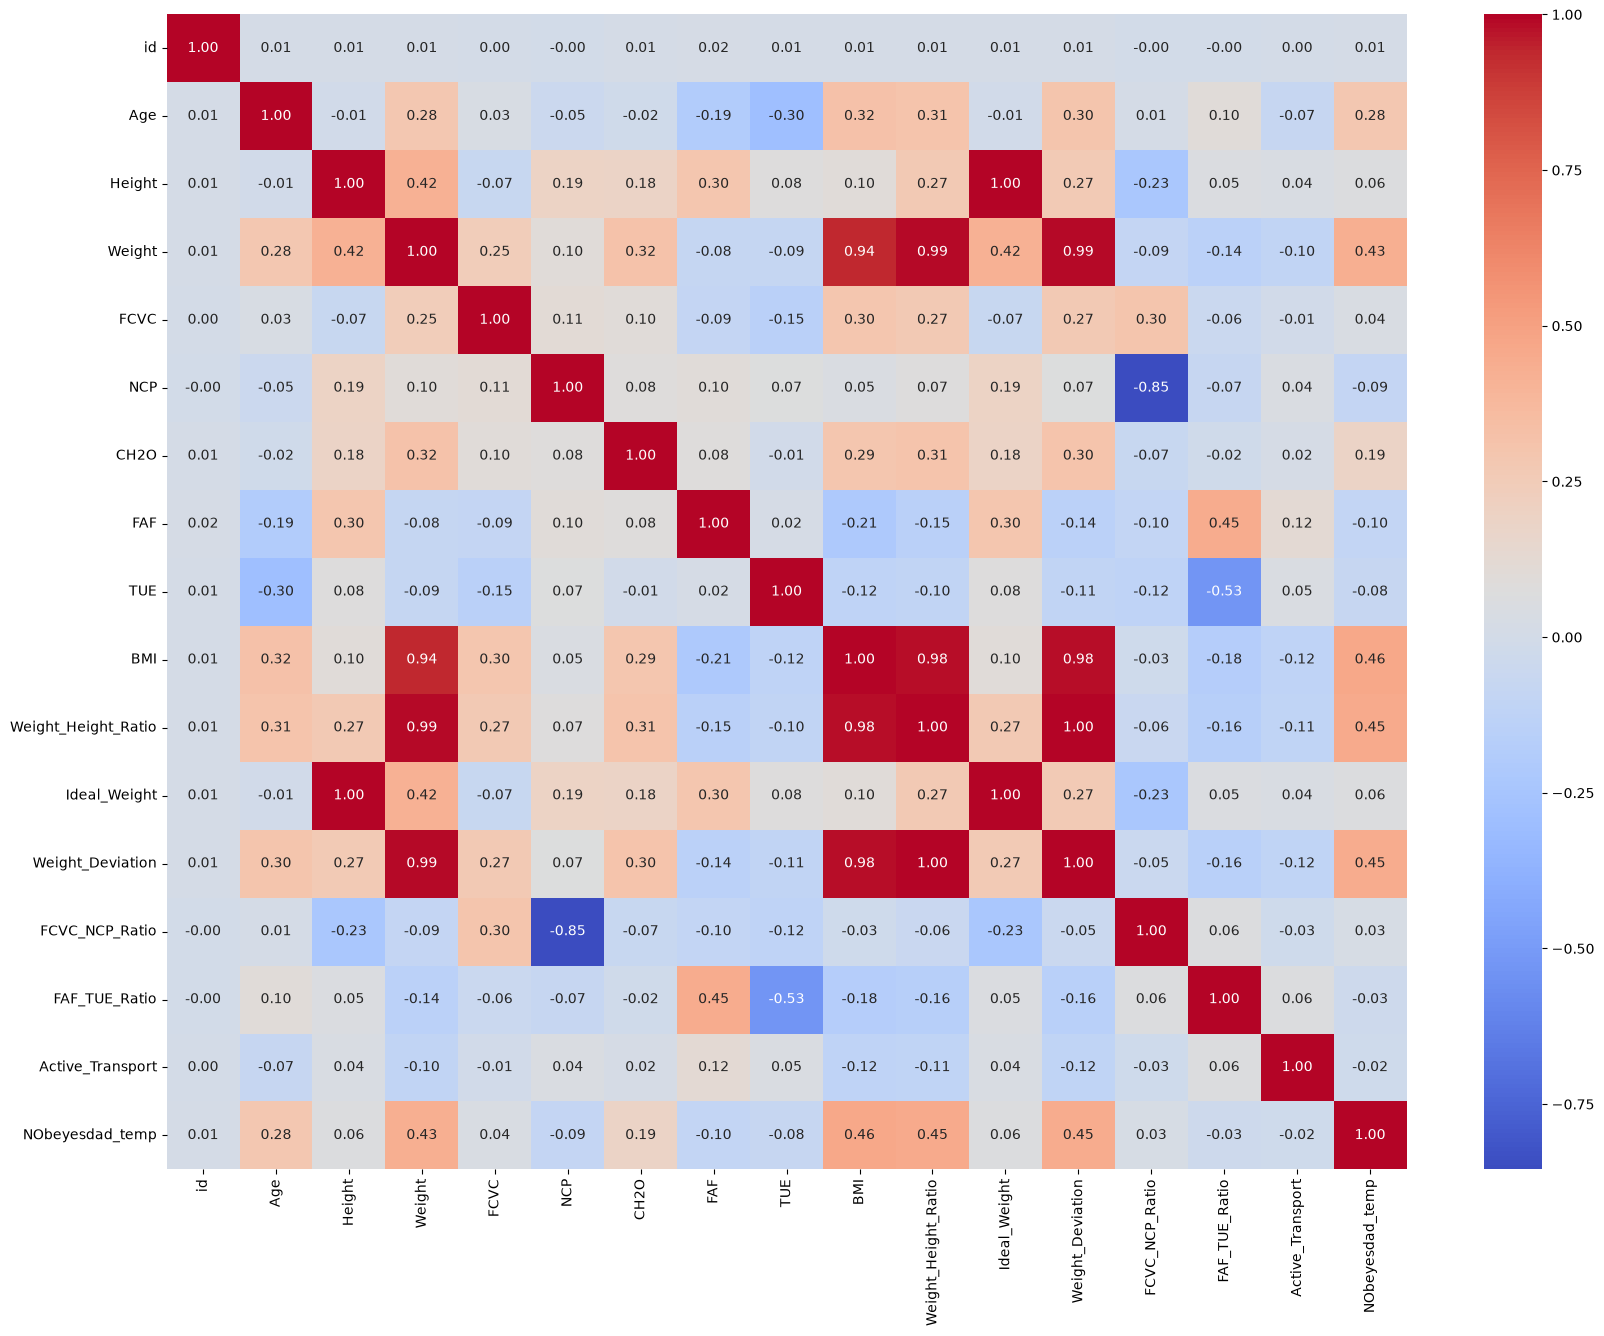

In [11]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

temp_target = LabelEncoder().fit_transform(train_data['NObeyesdad'])

numeric_cols = train_data.select_dtypes(include=['float64', 'int64']).columns
corr = train_data[numeric_cols].copy()
corr['NObeyesdad_temp'] = temp_target

corr= corr.corr()

plt.figure(figsize=(20,15))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [12]:
train_data = train_data.drop(['id'] , axis=1)

test_data = test_data.drop('id', axis=1)

train_data.shape , test_data.shape

((20758, 25), (13840, 24))

### Label Encoder

In [13]:
train_data['is_train'] = 1
test_data['is_train'] = 0

target_col = train_data['NObeyesdad']
train_data_no_target = train_data.drop(columns=['NObeyesdad'])

combined = pd.concat([train_data_no_target, test_data], axis=0, ignore_index=True)

cat_cols = combined.select_dtypes(include=['object', 'category']).columns

encoders = {}  # نخزنهم لو محتاجينهم بعدين (inverse_transform مثلاً)
for col in cat_cols:
    encoder = LabelEncoder()
    combined[col] = encoder.fit_transform(combined[col])
    encoders[col] = encoder

train_data = combined[combined['is_train'] == 1].drop(columns=['is_train']).reset_index(drop=True)
test_data = combined[combined['is_train'] == 0].drop(columns=['is_train']).reset_index(drop=True)

target_encoder = LabelEncoder()
train_data['NObeyesdad'] = target_encoder.fit_transform(target_col.reset_index(drop=True))


jb.dump( encoders , '../models/features_encoder.pkl')
jb.dump( target_encoder , '../models/target_encoder.pkl')


C:\Users\B-UNIT\AppData\Local\Temp\ipykernel_16984\3422044983.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = combined.select_dtypes(include=['object', 'category']).columns


['../models/target_encoder.pkl']

In [14]:
train_data.dtypes.value_counts() , test_data.dtypes.value_counts()

(float64    14
 int64      11
 Name: count, dtype: int64,
 float64    14
 int64      10
 Name: count, dtype: int64)

In [15]:
train_data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,MTRANS,BMI,Weight_Height_Ratio,Ideal_Weight,Weight_Deviation,FCVC_NCP_Ratio,FAF_TUE_Ratio,Age_Group,Active_Transport,NObeyesdad
0,1,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,2,0,...,3,28.259565,48.041204,59.9999,21.670050,0.670399,0.000000,4,0,6
1,0,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,1,0,...,0,23.422091,36.538462,53.0000,4.000000,0.666666,0.999999,3,0,1
2,0,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,2,0,...,3,17.126706,29.311672,60.5730,-10.407246,1.332119,0.517479,3,0,0
3,0,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,2,0,...,3,44.855798,76.736160,60.5365,70.738351,1.000000,1.881393,4,0,4
4,1,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,2,0,...,3,25.599151,49.001536,70.7093,23.088755,1.359219,2.112189,0,0,6


In [16]:
train_data.to_csv('../datasets/processed/final_train.csv', index= False )
test_data.to_csv('../datasets/processed/final_test.csv' , index = False)